
                  SECTION 1 : VÉRIFICATION DE L'ENVIRONNEMENT                   
Vérification des bibliothèques (Pandas, Scikit-Learn, CatBoost, XGBoost)... ✅

               SECTION 2 : ACQUISITION ET EXPLORATION DES DONNÉES               
Le fichier de données a été chargé avec succès ✅

--- Aperçu des 5 premières lignes du jeu de données ---


,Geometry,Pore Area (Å²),Applied pressure (MPa),Feed Concentration (ppm),Temperature (°C),Pore Chemistry (Functionalization),Porosity (%),Water Flux (molecule/ns),Salt Rejection (%),DOI,log(flux+1)
0,Hexagonal,16.3,100.0,72000,27.0,OH,10.0,30.9280,99.8388,"10,1021/nl3012853",1.504172
1,Hexagonal,16.3,100.0,72000,27.0,OH,10.0,30.9275,99.8388,"10,1021/nl3012853",1.504165
2,Hexagonal,16.3,100.0,72000,27.0,OH,10.0,38.1400,96.5959,"10,1021/nl3012853",1.592621
3,Hexagonal,16.3,100.0,72000,27.0,OH,10.0,47.4230,98.6793,"10,1021/nl3012853",1.685052
4,Hexagonal,16.3,100.0,72000,27.0,OH,10.0,54.6395,98.6793,"10,1021/nl3012853",1.745383



--- Structure des colonnes et types de données ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465 entries, 0 to 464
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Geometry                            465 non-null    object 
 1   Pore Area (Å²)                      465 non-null    float64
 2   Applied pressure  (MPa)             465 non-null    float64
 3   Feed Concentration  (ppm)           465 non-null    int64  
 4   Temperature  (°C)                   465 non-null    float64
 5   Pore Chemistry (Functionalization)  465 non-null    object 
 6   Porosity (%)                        465 non-null    float64
 7   Water Flux (molecule/ns)            465 non-null    float64
 8   Salt Rejection (%)                  465 non-null    float64
 9   DOI                                 465 non-null    object 
 10  log(flux+1)                         465 non-null    float6

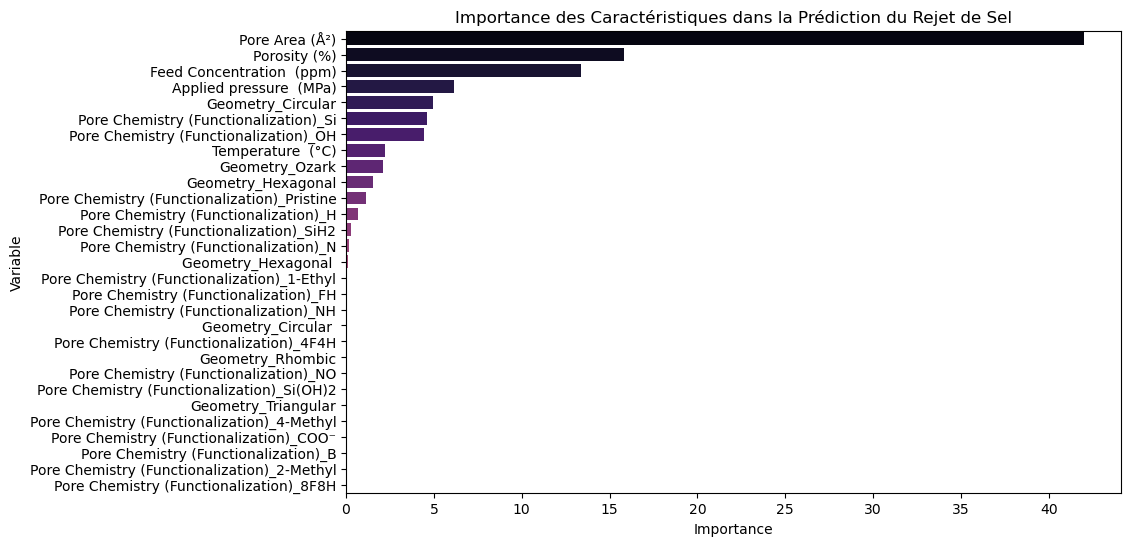

Génération du graphique de dispersion (Valeurs Réelles vs Prédites)...


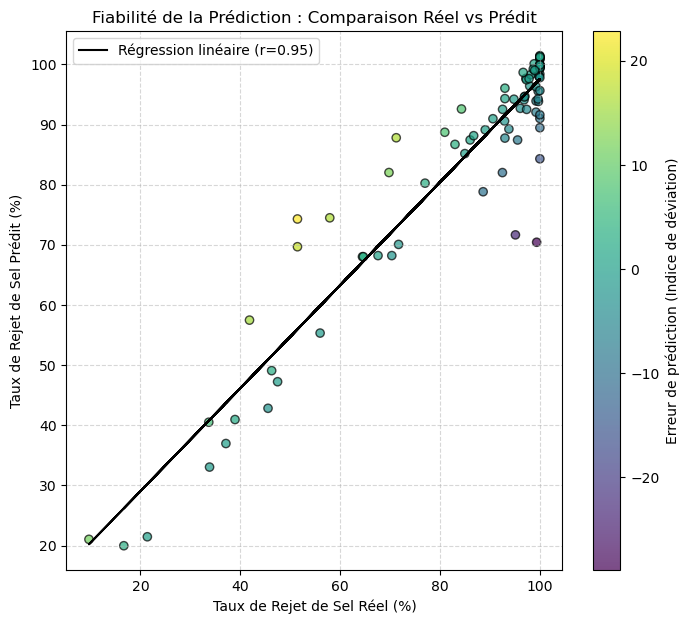


                          FIN DU RAPPORT SCIENTIFIQUE                           


In [4]:
#Salt Rejection (%)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy import stats
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# --- Fonction pour un affichage élégant des titres ---
def imprimer_titre(titre):
    print(f"\n{'='*80}")
    print(f"{titre:^80}")
    print(f"{'='*80}")

# --- Étape 1 : Vérification de l'environnement ---
imprimer_titre("SECTION 1 : VÉRIFICATION DE L'ENVIRONNEMENT")
print("Vérification des bibliothèques (Pandas, Scikit-Learn, CatBoost, XGBoost)... ✅")

# --- Étape 2 : Chargement et exploration des données ---
imprimer_titre("SECTION 2 : ACQUISITION ET EXPLORATION DES DONNÉES")
file_path = 'DATA ARTCLE 1 A 12 FINAL.xlsx'
df = pd.read_excel(file_path)
print("Le fichier de données a été chargé avec succès ✅")

print("\n--- Aperçu des 5 premières lignes du jeu de données ---")
display(df.head())

print("\n--- Structure des colonnes et types de données ---")
print(df.info())

# --- Étape 3 : Identification des variables ---
features_columns = ['Geometry', 'Pore Area (Å²)', 'Applied pressure  (MPa)', 
                    'Feed Concentration  (ppm)', 'Temperature  (°C)', 
                    'Pore Chemistry (Functionalization)', 'Porosity (%)']
target_column = 'Salt Rejection (%)'

print(f"\nVariables d'entrée (Features) identifiées : {features_columns}")
print(f"Variable cible (Target) identifiée : {target_column} ✅")

# --- Étape 4 : Prétraitement des données (Configuration Orange) ---
imprimer_titre("SECTION 3 : PRÉTRAITEMENT DES DONNÉES (PIPELINE)")
# Basé sur la source [5] : Preprocess Orange
numeric_features = ['Pore Area (Å²)', 'Applied pressure  (MPa)', 'Feed Concentration  (ppm)', 'Temperature  (°C)', 'Porosity (%)']
categorical_features = ['Geometry', 'Pore Chemistry (Functionalization)']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()) # Normalize μ=0, σ²=1
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # One feature per value
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Configuration du prétraitement terminée :")
print("- Normalisation standard (μ=0, σ²=1) appliquée aux variables numériques.")
print("- Encodage 'One-Hot' (Une caractéristique par valeur) appliqué aux variables discrètes.")
print("- Imputation des valeurs manquantes par la moyenne/mode effectuée. ✅")

# --- Étape 5 : Entraînement sur 100% des données (Cross-Validation) ---
imprimer_titre("SECTION 4 : ÉVALUATION PAR VALIDATION CROISÉE (10-FOLDS)")
print("Lancement de l'évaluation sur l'intégralité des données (100%) via Cross-Validation...")

models = {
    "CatBoost": CatBoostRegressor(iterations=1000, learning_rate=0.05, l2_leaf_reg=3, depth=6, random_seed=42, verbose=0),
    "XGBoost": XGBRegressor(n_estimators=1000, learning_rate=0.05, reg_lambda=1, max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_features=5, max_depth=10, min_samples_split=5, random_state=42)
}

kf = KFold(n_splits=10, shuffle=True, random_state=42)
scoring = {'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    cv_res = cross_validate(pipe, df[features_columns], df[target_column], cv=kf, scoring=scoring)
    print(f"Modèle : {name:<15} | R² Moyen : {cv_res['test_r2'].mean():.4f} | RMSE Moyen : {abs(cv_res['test_rmse'].mean()):.4f}")

# --- Étape 6 : Test indépendant (Split 80/20) ---
imprimer_titre("SECTION 5 : VALIDATION SUR DONNÉES INCONNUES (SPLIT 80/20)")
print("Division des données : 80% pour l'entraînement et 20% pour le test final.")
X_train, X_test, y_train, y_test = train_test_split(df[features_columns], df[target_column], test_size=0.20, random_state=42)

print("Application du domaine de prétraitement sans fuite de données (Data Leakage Protection) ✅")

print("\n--- Résultats de performance sur le jeu de test (20%) ---")
for name, model in models.items():
    final_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    final_pipe.fit(X_train, y_train)
    y_pred = final_pipe.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"Modèle : {name:<15} | R² Test : {r2:.4f} | RMSE Test : {rmse:.4f}")

# --- Étape 7 : Visualisations ---
imprimer_titre("SECTION 6 : ANALYSES GRAPHIQUES FINALES")

# Graphique 1 : Importance des variables
print("Génération du graphique d'importance des variables (Modèle CatBoost Final)...")
model_final = Pipeline(steps=[('preprocessor', preprocessor), ('model', models["CatBoost"])])
model_final.fit(X_train, y_train)

cat_names = model_final.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_names = numeric_features + list(cat_names)
importances = model_final.named_steps['model'].get_feature_importance()
feat_df = pd.DataFrame({'Variable': all_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Variable', data=feat_df, hue='Variable', palette='magma', legend=False)
plt.title('Importance des Caractéristiques dans la Prédiction du Rejet de Sel')
plt.show()

# Graphique 2 : Scatter Plot (Actual vs Predicted)
print("Génération du graphique de dispersion (Valeurs Réelles vs Prédites)...")
plt.figure(figsize=(8, 7))
y_pred_test = model_final.predict(X_test)
err = y_pred_test - y_test
plt.scatter(y_test, y_pred_test, c=err, cmap='viridis', edgecolors='k', alpha=0.7)
plt.colorbar(label='Erreur de prédiction (Indice de déviation)')
slope, intercept, r_val, _, _ = stats.linregress(y_test, y_pred_test)
plt.plot(y_test, slope*y_test + intercept, color='black', label=f'Régression linéaire (r={r_val:.2f})')
plt.xlabel('Taux de Rejet de Sel Réel (%)')
plt.ylabel('Taux de Rejet de Sel Prédit (%)')
plt.title('Fiabilité de la Prédiction : Comparaison Réel vs Prédit')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

imprimer_titre("FIN DU RAPPORT SCIENTIFIQUE")


                  SECTION 1 : VÉRIFICATION DE L'ENVIRONNEMENT                   
Vérification des bibliothèques (Pandas, Scikit-Learn, CatBoost, XGBoost)... ✅

               SECTION 2 : ACQUISITION ET EXPLORATION DES DONNÉES               
Le fichier de données a été chargé avec succès ✅

--- Aperçu des 5 premières lignes (Cible : log(flux+1)) ---


,Geometry,Pore Area (Å²),Applied pressure (MPa),Feed Concentration (ppm),Temperature (°C),Pore Chemistry (Functionalization),Porosity (%),Water Flux (molecule/ns),Salt Rejection (%),DOI,log(flux+1)
0,Hexagonal,16.3,100.0,72000,27.0,OH,10.0,30.9280,99.8388,"10,1021/nl3012853",1.504172
1,Hexagonal,16.3,100.0,72000,27.0,OH,10.0,30.9275,99.8388,"10,1021/nl3012853",1.504165
2,Hexagonal,16.3,100.0,72000,27.0,OH,10.0,38.1400,96.5959,"10,1021/nl3012853",1.592621
3,Hexagonal,16.3,100.0,72000,27.0,OH,10.0,47.4230,98.6793,"10,1021/nl3012853",1.685052
4,Hexagonal,16.3,100.0,72000,27.0,OH,10.0,54.6395,98.6793,"10,1021/nl3012853",1.745383



Variables d'entrée (Features) : ['Geometry', 'Pore Area (Å²)', 'Applied pressure  (MPa)', 'Feed Concentration  (ppm)', 'Temperature  (°C)', 'Pore Chemistry (Functionalization)', 'Porosity (%)']
Nouvelle Variable cible (Target) : log(flux+1) ✅
Variable informative (Meta) : Salt Rejection (%) (Exclue de l'entraînement) ✅

                SECTION 3 : PRÉTRAITEMENT DES DONNÉES (PIPELINE)                
Configuration du prétraitement terminée :
- Normalisation standard (μ=0, σ²=1) appliquée aux variables numériques.
- Encodage 'One-Hot' appliqué aux variables discrètes.
- Protection contre la fuite de données activée via Pipeline. ✅

            SECTION 4 : ÉVALUATION PAR VALIDATION CROISÉE (10-FOLDS)            
Analyse de la performance pour la prédiction de log(flux+1)...
Modèle : CatBoost        | R² Moyen : 0.9285 | RMSE Moyen : 0.1664
Modèle : XGBoost         | R² Moyen : 0.9096 | RMSE Moyen : 0.1842
Modèle : Random Forest   | R² Moyen : 0.8428 | RMSE Moyen : 0.2598

           SECT

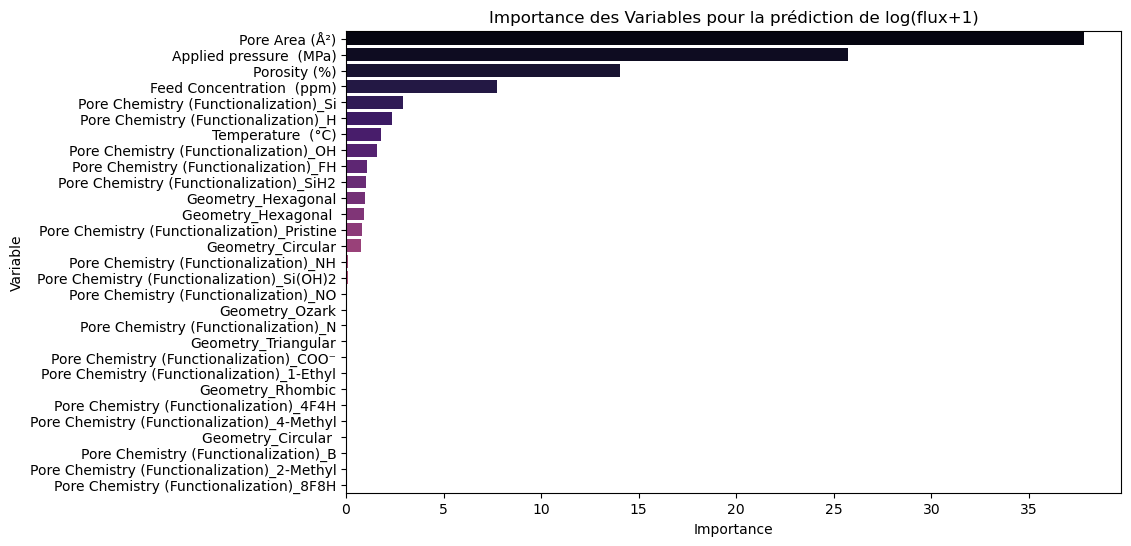

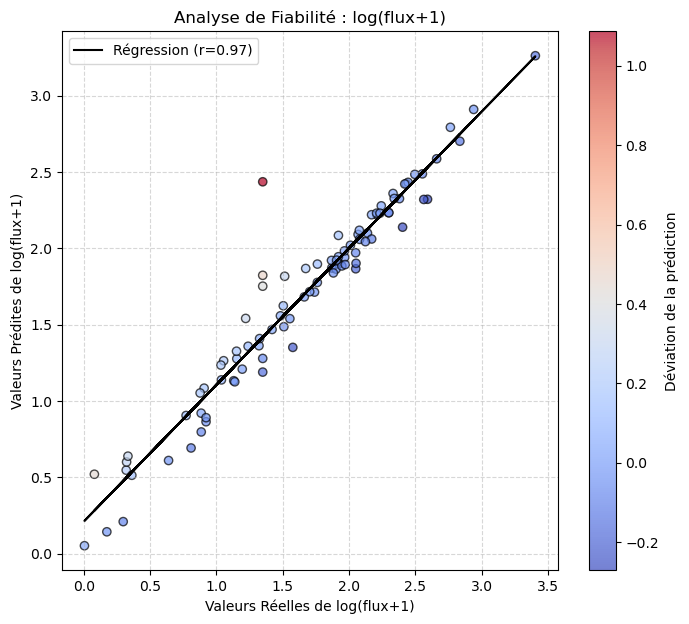


                          FIN DU RAPPORT SCIENTIFIQUE                           


In [5]:
#log(flux+1) , #flyx=Water Flux (molecule/ns)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# --- Fonction pour un affichage élégant des titres ---
def imprimer_titre(titre):
    print(f"\n{'='*80}")
    print(f"{titre:^80}")
    print(f"{'='*80}")

# --- Étape 1 : Vérification de l'environnement ---
imprimer_titre("SECTION 1 : VÉRIFICATION DE L'ENVIRONNEMENT")
print("Vérification des bibliothèques (Pandas, Scikit-Learn, CatBoost, XGBoost)... ✅")

# --- Étape 2 : Chargement et exploration des données ---
imprimer_titre("SECTION 2 : ACQUISITION ET EXPLORATION DES DONNÉES")
file_path = 'DATA ARTCLE 1 A 12 FINAL.xlsx'
df = pd.read_excel(file_path)
print("Le fichier de données a été chargé avec succès ✅")

print("\n--- Aperçu des 5 premières lignes (Cible : log(flux+1)) ---")
display(df.head())

# --- Étape 3 : Identification des variables (Nouvelle Configuration) ---
features_columns = ['Geometry', 'Pore Area (Å²)', 'Applied pressure  (MPa)', 
                    'Feed Concentration  (ppm)', 'Temperature  (°C)', 
                    'Pore Chemistry (Functionalization)', 'Porosity (%)']

target_column = 'log(flux+1)'  # Nouvelle cible demandée
meta_column = 'Salt Rejection (%)' # Variable déplacée en Meta

print(f"\nVariables d'entrée (Features) : {features_columns}")
print(f"Nouvelle Variable cible (Target) : {target_column} ✅")
print(f"Variable informative (Meta) : {meta_column} (Exclue de l'entraînement) ✅")

# --- Étape 4 : Prétraitement des données (Configuration Orange) ---
imprimer_titre("SECTION 3 : PRÉTRAITEMENT DES DONNÉES (PIPELINE)")
# Basé sur la source : Preprocess Orange [1]
numeric_features = ['Pore Area (Å²)', 'Applied pressure  (MPa)', 'Feed Concentration  (ppm)', 'Temperature  (°C)', 'Porosity (%)']
categorical_features = ['Geometry', 'Pore Chemistry (Functionalization)']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()) # Normalize μ=0, σ²=1 [1]
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # One feature per value [1]
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Configuration du prétraitement terminée :")
print("- Normalisation standard (μ=0, σ²=1) appliquée aux variables numériques.")
print("- Encodage 'One-Hot' appliqué aux variables discrètes.")
print("- Protection contre la fuite de données activée via Pipeline. ✅")

# --- Étape 5 : Évaluation sur 100% des données (Cross-Validation) ---
imprimer_titre("SECTION 4 : ÉVALUATION PAR VALIDATION CROISÉE (10-FOLDS)")
print(f"Analyse de la performance pour la prédiction de {target_column}...")

# Paramètres extraits des sources [1, 2]
models = {
    "CatBoost": CatBoostRegressor(iterations=1000, learning_rate=0.05, l2_leaf_reg=3, depth=6, random_seed=42, verbose=0),
    "XGBoost": XGBRegressor(n_estimators=1000, learning_rate=0.05, reg_lambda=1, max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_features=5, max_depth=10, min_samples_split=5, random_state=42)
}

kf = KFold(n_splits=10, shuffle=True, random_state=42)
scoring = {'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    cv_res = cross_validate(pipe, df[features_columns], df[target_column], cv=kf, scoring=scoring)
    print(f"Modèle : {name:<15} | R² Moyen : {cv_res['test_r2'].mean():.4f} | RMSE Moyen : {abs(cv_res['test_rmse'].mean()):.4f}")

# --- Étape 6 : Test indépendant (Split 80/20) ---
imprimer_titre("SECTION 5 : VALIDATION SUR DONNÉES INCONNUES (SPLIT 80/20)")
X_train, X_test, y_train, y_test = train_test_split(df[features_columns], df[target_column], test_size=0.20, random_state=42)

print("Entraînement sur 80% des données et test sur les 20% restants... ✅")

for name, model in models.items():
    final_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    final_pipe.fit(X_train, y_train)
    y_pred = final_pipe.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"Modèle : {name:<15} | R² Test : {r2:.4f} | RMSE Test : {rmse:.4f}")

# --- Étape 7 : Visualisations Finales ---
imprimer_titre("SECTION 6 : ANALYSES GRAPHIQUES (CATBOOST FINAL)")

# Importance des variables
model_final = Pipeline(steps=[('preprocessor', preprocessor), ('model', models["CatBoost"])])
model_final.fit(X_train, y_train)

cat_names = model_final.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_names = numeric_features + list(cat_names)
importances = model_final.named_steps['model'].get_feature_importance()
feat_df = pd.DataFrame({'Variable': all_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Variable', data=feat_df, hue='Variable', palette='magma', legend=False)
plt.title(f'Importance des Variables pour la prédiction de {target_column}')
plt.show()

# Scatter Plot (Réel vs Prédit)
plt.figure(figsize=(8, 7))
y_pred_test = model_final.predict(X_test)
err = y_pred_test - y_test
plt.scatter(y_test, y_pred_test, c=err, cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.colorbar(label='Déviation de la prédiction')
slope, intercept, r_val, _, _ = stats.linregress(y_test, y_pred_test)
plt.plot(y_test, slope*y_test + intercept, color='black', label=f'Régression (r={r_val:.2f})')
plt.xlabel(f'Valeurs Réelles de {target_column}')
plt.ylabel(f'Valeurs Prédites de {target_column}')
plt.title(f'Analyse de Fiabilité : {target_column}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

imprimer_titre("FIN DU RAPPORT SCIENTIFIQUE")